In [1]:
import sys
homedir = '../'

In [2]:
from __future__ import division

import numpy as np
import os, glob, json
import matplotlib.pyplot as plt
import corner

import enterprise
from enterprise.pulsar import Pulsar
from enterprise.signals import utils
from enterprise_extensions import models, model_utils, hypermodel
from enterprise_extensions.sampler import JumpProposal

from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from types import SimpleNamespace

from concurrent.futures import ProcessPoolExecutor

/home/llaett/projects/thesis/master-thesis-code/.venv/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
PINT not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


In [7]:
options = SimpleNamespace()
options.basedir =  f'{homedir}data/'
options.dataset = 'DR2new+'
options.datadir = os.path.join(options.basedir, options.dataset)
# options.noisedir = os.path.join(options.basedir, 'noisefiles', options.dataset)
options.noisedir = os.path.join(options.basedir, 'noisefiles_t2equad', options.dataset)
options.red_components =  0
options.dm_components =  0
options.chrom_components =  0
options.common_components =  30
options.common_psd =  'powerlaw'
options.common_components =  30
options.gamma_common =  None
options.red_components =  0
options.dm_components =  0
options.chrom_components =  0
options.num_dmdips =  2
options.bayesephem =  False
options.common_sin =  False
options.psrname =  'string'
options.resume =  False
options.emp =  None
options.number =  1e7
options.thin =  100
options.PsrList = ['J0613-0200','J1012+5307','J1600-3053','J1713+0747','J1744-1134','J1909-3744']
options.orf_bins = None
options.orf = 'crn'

# Load par+tim+noise files


In [16]:
parfiles = sorted(glob.glob( options.datadir  + '/J*/*.par'))
timfiles = sorted(glob.glob( options.datadir  + '/J*/*_all.tim'))
noisefiles = sorted(glob.glob( options.noisedir  + '/*.json'))

parfiles = [x for x in parfiles if x.split('/')[-1].split('.')[0] in  options.PsrList ]
timfiles = [x for x in timfiles if x.split('/')[-1].split('_')[0] in  options.PsrList ]
noisefiles = [x for x in noisefiles if x.split('/')[-1].split('_')[0] in  options.PsrList ]

params = {}
for nf in noisefiles:
    with open(nf, 'r') as fin:
        params.update(json.load(fin))


def create_pulsar(parfile, timfile):
    return Pulsar(parfile, timfile, ephem='DE440')

# Create pulsar objects in parallel
psrs = []

for par, tim in zip(parfiles, timfiles):
        psrs.append(create_pulsar(par, tim))

# Check the number of pulsars created
print(f"Number of pulsar objects created: {len(psrs)}")

Current filename = J0613-0200_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new+/J0613-0200/tims/EFF.P200.1380.tim
Current filename = J0613-0200_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new+/J0613-0200/tims/EFF.P217.1380.tim
Current filename = J0613-0200_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new+/J0613-0200/tims/EFF.S110.2487.tim
Current filename = J0613-0200_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new+/J0613-0200/tims/GM_GWB_1460_200_b0_post36.tim
Current filename = J0613-0200_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new+/J0613-0200/tims/GM_GWB_500_100_b1_pre36.tim
Current filename = J0613-0200_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/DR2new+/J0613-0200/tims/GM_GWB_500_200_b1_post36.tim
Current filename = J0613-0200_all.tim
Rel path = /home/llaett/projects/thesis/master-thesis-code/data/D

In [17]:
# load noise models and files
params = {}
for nf in noisefiles:
    with open(nf, 'r') as fin:
        params.update(json.load(fin))

if not options.red_components:
    try:
        red_dict = {}
        with open( options.noisedir  + '/red_dict.json','r') as rd:
            red_dict.update(json.load(rd))
    except:
        raise UserWarning('Custom pulsar red noise frequency components not set.')
else:
    red_dict = options.red_components

if not options.dm_components:
    try:
        dm_dict = {}
        with open( options.noisedir  + '/dm_dict.json','r') as dd:
            dm_dict.update(json.load(dd))
    except:
        raise UserWarning('Custom pulsar DM noise frequency components not set.')
else:
    dm_dict = options.dm_components

if not options.chrom_components:
    try:
        chrom_dict = {}
        with open( options.noisedir  + '/chrom_dict.json','r') as cd:
            chrom_dict.update(json.load(cd))
    except:
        raise UserWarning('Custom pulsar scattering noise frequency components not set.')
else:
    chrom_dict = options.chrom_components

try:
    gamma_common = float(options.gamma_common)
except:
    gamma_common = None

if options.psrname is not None:
    dropout = True
else:
    dropout = False

if options.orf_bins is not None:
    orf_bins = np.loadtxt(options.orf_bins)
else:
    orf_bins = None

Assuming purely GW emission driven circular binaries allows one to write the strain of the GWB to be
\begin{equation}
\large
h_c (f) = A_{GWB} f^{-2/3}
\end{equation}

The characteristic strain $h_c$ is connected to the induced correlated red noise between two pulsars $i$ and $j$ via the power spectral density (which is the Fourier transform of the common residuals $R_{ij}(t)$ between pulsars $i$ and $j$)
\begin{equation}
\large
S_{ij}(f) = \Gamma_{ij} \frac{h_c^2(f)}{12\pi^2 f^3}
\end{equation}
where $\Gamma_{ij}$ is the overlap reduction function and describes the degree of correlation between the noise in the pulsar pair $ij$, in case of an isotropic GWB it is the Hellings-Downs curve.

We can put $h_c$ into the PSD equation to get
\begin{equation}
\large
S_{ij}(f) = \Gamma_{ij} \frac{A_{GWB}^2 f^{-4/3}}{12\pi^2 f^3} = \frac{\Gamma_{ij}}{12\pi^2} A_{GWB}^2 f^{-13/3}
\end{equation}

White noise parameters are used fixed for the GWB analysis. See Gregory+Antoine tutorial on how to get EFAC+EQUAD.

To speed computation we usually assume that the overlap reduction function is just the identity matrix, ie. common red noise process with no spatial correlation. But HD correlated red noise search is done as a final confirmation.

When searching for a background, sometimes the $-\gamma=-13/3$ restriction is loosened to be $\gamma \in [0,7]$. This is equivalent to searching for a common red noise amongst all pulsars with a unknown spectral index and amplitude.

# GWB

In [10]:
# create PTA object
pta = models.model_general(psrs, noisedict=params, orf=options.orf, 
                           gamma_common=13./3., upper_limit_common=True, 
                           bayesephem=True, dm_var=True)

In [11]:
# draw initial sample
x0 = np.hstack([p.sample() for p in pta.params])

In [12]:
x0

array([ 6.08990481e+00, -1.79940441e+01,  7.48554716e-01, -1.78123892e+01,
        4.94393236e-01, -1.37257802e+01,  2.69782578e-01, -1.41419697e+01,
        2.90198380e+00, -1.86457445e+01,  6.58565639e-01, -1.72289689e+01,
        5.85011504e+00, -1.43867545e+01, -3.17795196e+00,  1.34601501e+00,
        5.79585717e+04,  1.90139722e-01, -1.33016992e+01,  6.02378494e+00,
       -1.24205106e+01,  2.66874923e+00, -1.36826972e+01,  8.98172004e-01,
       -1.81255316e+01,  4.49771868e+00, -1.10768757e+01, -2.26115924e-12,
        4.67559166e-11, -2.07679595e-12, -1.44007301e-11,  2.70045832e-10,
       -1.14040402e+01, -1.75229373e-02, -3.75882235e-02,  2.70307641e-02,
        8.32306833e-03, -1.32836277e-02,  4.33367638e-02])

In [18]:
# PTMCMC

# set output directory
outdir = '../chains/ptmcmc_test'
! mkdir -p {outdir}

# save parameter names
np.savetxt(outdir+'/pars.txt', pta.param_names, fmt='%s')

ndim = len(x0)
N = int(1e5)

# initial jump covariance matrix
cov = np.diag(np.ones(ndim) * 0.01**2)

sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir=outdir, resume=False)

# jump proposals
#jp = JumpProposal(pta)     #taking jumps out helps avoiding error... but i just took them out no idea why yet
#sampler.addProposalToCycle(jp.draw_from_prior,15) #taking jumps out helps

In [19]:
# SCAM = Single Component Adaptive Metropolis
# AM = Adaptive Metropolis
# DE = Differential Evolution
## You can keep all these set at default values
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Finished 5.00 percent in 176.943175 s Acceptance rate = 0.24925

KeyboardInterrupt: 

In [21]:
chain = np.genfromtxt(f"{outdir}/chain_1.txt")
names = np.loadtxt(f"{outdir}/pars.txt",dtype=str)
chain = np.delete(chain,[chain.shape[1]-1,chain.shape[1]-2,chain.shape[1]-3,chain.shape[1]-4],1)
burn = int(0.25 * chain.shape[0])

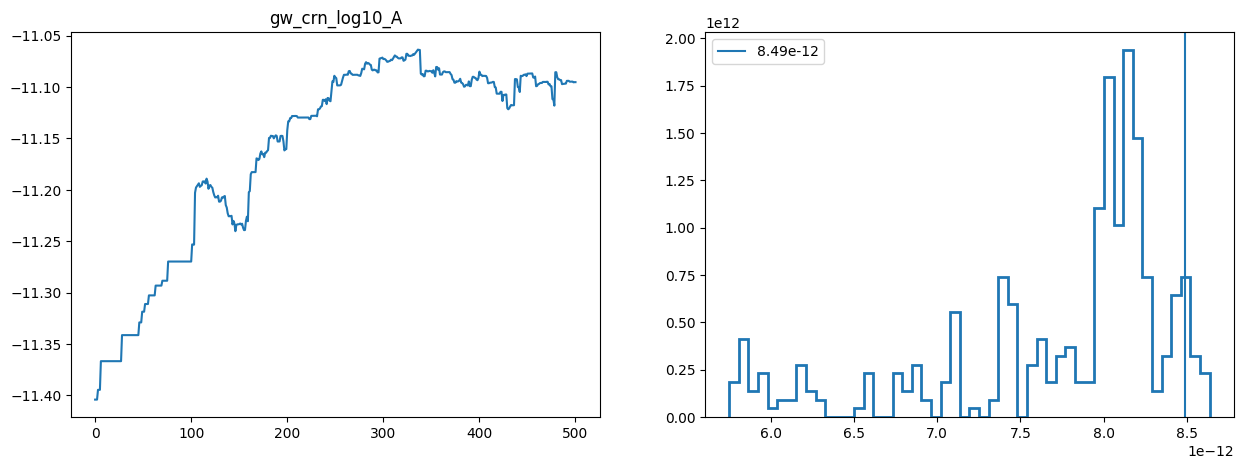

In [22]:
# plot chain and posterior

s = 7 # 7 ptmcmc, 1 single

fig = plt.figure(figsize=(15,5))
plt.subplot(121)
plt.title('{}'.format(names[-s]))
plt.plot(range(len(chain)),chain[:,-s])

plt.subplot(122)
uplim = 10.**np.percentile(chain[burn:,-s],95)
plt.hist(10.**chain[burn:,-s], 50, density=True, histtype='step', lw=2)
plt.axvline(uplim,label="{:.2e}".format(uplim))
plt.legend(loc=0)

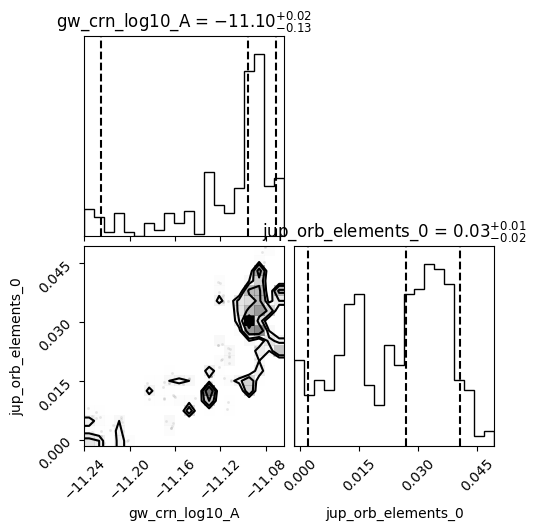

In [23]:
# corner plot
corner.corner(chain[burn:,[-7,-6]],labels=[names[-7],names[-6]],show_titles=1,quantiles=[0.05,0.5,0.95])
plt.show()